# Non-stationary Example: Input Warping vs Baseline Matern

This notebook demonstrates a case where the process evolves on a nonlinear time axis.

We compare:
- Stationary Matern 5/2 baseline
- Matern 5/2 + Kumaraswamy input warping on time

In [ ]:
import pathlib
import sys

repo_root = pathlib.Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from gparchitect.builders.builder import build_model_from_dsl
from gparchitect.dsl.schema import (
    CompositionType,
    ExecutionSpec,
    FeatureGroupSpec,
    GPSpec,
    InputWarpingSpec,
    KernelSpec,
    KernelType,
    ModelClass,
    NoiseSpec,
    PriorDistribution,
    PriorSpec,
    WarpType,
)
from gparchitect.fitting.fitter import fit_and_validate

torch.set_default_dtype(torch.double)
torch.manual_seed(11)
np.random.seed(11)

In [2]:
# Synthetic dataset: latent process is smooth in warped-time space, not raw time
n = 260
t = np.linspace(0.0, 1.0, n)
tau = np.sqrt(t + 1e-3)
signal = np.sin(4.0 * math.pi * tau) + 0.25 * np.cos(12.0 * math.pi * tau)
noise = np.random.normal(0.0, 0.07, size=n)
y = signal + noise

df = pd.DataFrame({"time": t, "time_warp_true": tau, "target": y})
df.head()

,time,time_warp_true,target
0,0.000000,0.031623,0.601885
1,0.003861,0.069721,0.530450
2,0.007722,0.093392,0.655986
3,0.011583,0.112174,0.685081
4,0.015444,0.128234,1.029001


Why warping may help: the dynamics look more stationary after nonlinear time transformation.


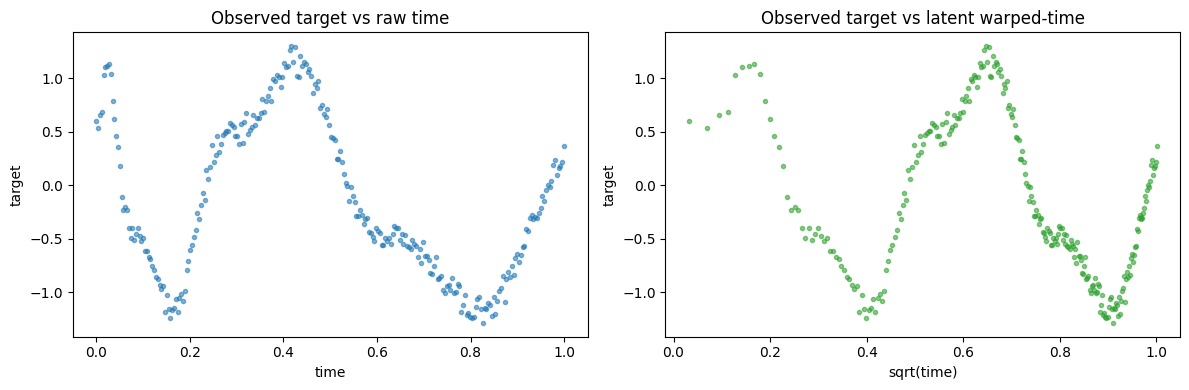

In [3]:
# EDA: compare signal shape on raw time vs warped-time axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df["time"], df["target"], ".", alpha=0.55)
axes[0].set_title("Observed target vs raw time")
axes[0].set_xlabel("time")
axes[0].set_ylabel("target")

axes[1].plot(df["time_warp_true"], df["target"], ".", alpha=0.55, color="tab:green")
axes[1].set_title("Observed target vs latent warped-time")
axes[1].set_xlabel("sqrt(time)")
axes[1].set_ylabel("target")

plt.tight_layout()
print("Why warping may help: the dynamics look more stationary after nonlinear time transformation.")

In [4]:
split_idx = int(0.7 * n)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

train_X = torch.tensor(train_df[["time"]].values, dtype=torch.double)
train_Y = torch.tensor(train_df[["target"]].values, dtype=torch.double)
test_X = torch.tensor(test_df[["time"]].values, dtype=torch.double)
test_Y = torch.tensor(test_df[["target"]].values, dtype=torch.double)

In [5]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def nll_gaussian(y_true: np.ndarray, mean: np.ndarray, var: np.ndarray, eps: float = 1e-8) -> float:
    var_safe = np.maximum(var, eps)
    return float(np.mean(0.5 * np.log(2.0 * np.pi * var_safe) + 0.5 * ((y_true - mean) ** 2) / var_safe))


def fit_predict(spec: GPSpec, train_X: torch.Tensor, train_Y: torch.Tensor, test_X: torch.Tensor) -> dict:
    model = build_model_from_dsl(spec, train_X, train_Y)
    fit_result = fit_and_validate(model, train_X, train_Y)
    if not fit_result.success:
        raise RuntimeError(f"Fit failed: {fit_result.error_message}")

    fitted = fit_result.model
    fitted.eval()
    fitted.likelihood.eval()

    with torch.no_grad():
        posterior = fitted.posterior(test_X)
        mean = posterior.mean.squeeze(-1).cpu().numpy()
        var = posterior.variance.squeeze(-1).cpu().numpy()

    return {"model": fitted, "mean": mean, "var": var}

In [6]:
baseline_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.MATERN_52,
                composition=CompositionType.ADDITIVE,
                children=[
                    KernelSpec(kernel_type=KernelType.MATERN_52),
                    KernelSpec(kernel_type=KernelType.PERIODIC, ard=True),
                ],
            ),
        )
    ],
    input_dim=1,
    output_dim=1,
)

warped_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.MATERN_52,
                composition=CompositionType.ADDITIVE,
                children=[
                    KernelSpec(kernel_type=KernelType.MATERN_52),
                    KernelSpec(kernel_type=KernelType.PERIODIC, ard=True),
                ],
            ),
        )
    ],
    execution=ExecutionSpec(
        input_scaling=True,
        outcome_standardization=True,
        input_warping=InputWarpingSpec(
            warp_type=WarpType.KUMARASWAMY,
            time_feature_index=0,
            concentration0=1.8,
            concentration1=0.7,
        ),
    ),
    input_dim=1,
    output_dim=1,
)

lengthscale_prior = PriorSpec(
    distribution=PriorDistribution.LOG_NORMAL,
    params={"loc": -1.2, "scale": 0.4},
)
period_prior = PriorSpec(
    distribution=PriorDistribution.LOG_NORMAL,
    params={"loc": -1.0, "scale": 0.5},
)
noise_prior = PriorSpec(
    distribution=PriorDistribution.LOG_NORMAL,
    params={"loc": -3.2, "scale": 0.4},
)

warped_conservative_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.MATERN_52,
                composition=CompositionType.ADDITIVE,
                children=[
                    KernelSpec(kernel_type=KernelType.MATERN_52, lengthscale_prior=lengthscale_prior),
                    KernelSpec(
                        kernel_type=KernelType.PERIODIC,
                        ard=True,
                        lengthscale_prior=lengthscale_prior,
                        period_prior=period_prior,
                    ),
                ],
            ),
        )
    ],
    noise=NoiseSpec(fixed=False, prior=noise_prior),
    execution=ExecutionSpec(
        input_scaling=True,
        outcome_standardization=True,
        input_warping=InputWarpingSpec(
            warp_type=WarpType.KUMARASWAMY,
            time_feature_index=0,
            concentration0=1.5,
            concentration1=0.7,
        ),
    ),
    input_dim=1,
    output_dim=1,
)

In [7]:
baseline = fit_predict(baseline_spec, train_X, train_Y, test_X)
warped = fit_predict(warped_spec, train_X, train_Y, test_X)
warped_conservative = fit_predict(warped_conservative_spec, train_X, train_Y, test_X)

y_true = test_Y.squeeze(-1).cpu().numpy()

metrics = pd.DataFrame(
    [
        {
            "model": "Matern52 baseline",
            "RMSE": rmse(y_true, baseline["mean"]),
            "MAE": mae(y_true, baseline["mean"]),
            "NLL": nll_gaussian(y_true, baseline["mean"], baseline["var"]),
        },
        {
            "model": "Matern52 + input warping",
            "RMSE": rmse(y_true, warped["mean"]),
            "MAE": mae(y_true, warped["mean"]),
            "NLL": nll_gaussian(y_true, warped["mean"], warped["var"]),
        },
        {
            "model": "Matern52 + conservative warping",
            "RMSE": rmse(y_true, warped_conservative["mean"]),
            "MAE": mae(y_true, warped_conservative["mean"]),
            "NLL": nll_gaussian(y_true, warped_conservative["mean"], warped_conservative["var"]),
        },
    ]
).sort_values("RMSE")

metrics

/Users/et/Library/Caches/pypoetry/virtualenvs/gparchitect-s_NfA0qk-py3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,model,RMSE,MAE,NLL
1,Matern52 + input warping,0.197434,0.157065,47.725223
2,Matern52 + conservative warping,0.730095,0.578533,0.654007
0,Matern52 baseline,0.741545,0.655771,1.609470


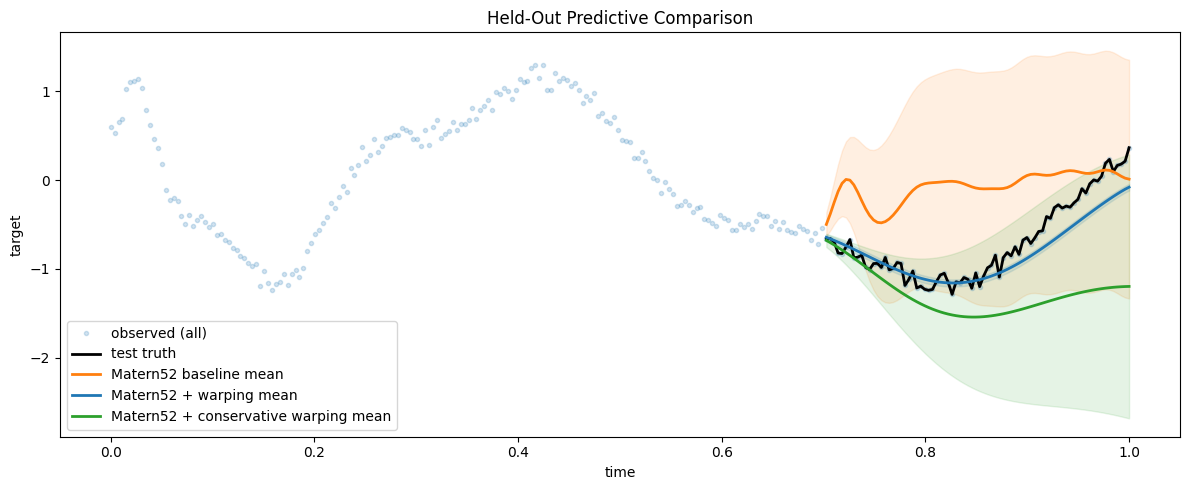

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["time"], df["target"], ".", alpha=0.2, label="observed (all)")
ax.plot(test_df["time"], y_true, color="black", linewidth=2, label="test truth")

for name, result, color in [
    ("Matern52 baseline", baseline, "tab:orange"),
    ("Matern52 + warping", warped, "tab:blue"),
    ("Matern52 + conservative warping", warped_conservative, "tab:green"),
]:
    mean = result["mean"]
    std = np.sqrt(np.maximum(result["var"], 1e-9))
    x = test_df["time"].to_numpy()
    ax.plot(x, mean, color=color, linewidth=2, label=f"{name} mean")
    ax.fill_between(x, mean - 1.96 * std, mean + 1.96 * std, color=color, alpha=0.12)

ax.set_title("Held-Out Predictive Comparison")
ax.set_xlabel("time")
ax.set_ylabel("target")
ax.legend(loc="best")
plt.tight_layout()

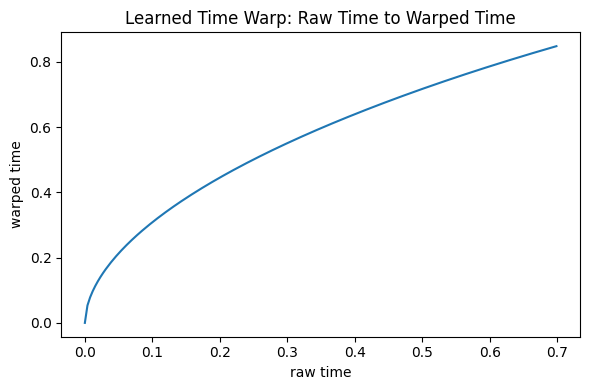

In [9]:
# Visualize learned warped time (if transform is available)
try:
    with torch.no_grad():
        warped_time = warped["model"].input_transform(train_X).squeeze(-1).cpu().numpy()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(train_df["time"].to_numpy(), warped_time, color="tab:blue")
    ax.set_title("Learned Time Warp: Raw Time to Warped Time")
    ax.set_xlabel("raw time")
    ax.set_ylabel("warped time")
    plt.tight_layout()
except Exception as exc:
    print("Could not visualize learned warp directly:", exc)

In [10]:
# Diagnostic: compare transformed train/test coordinates for the warped model
with torch.no_grad():
    transformed_train = warped["model"].input_transform(train_X).squeeze(-1).cpu().numpy()
    transformed_test = warped["model"].input_transform(test_X).squeeze(-1).cpu().numpy()

print("Raw ranges:")
print("  train:", float(train_X.min()), "->", float(train_X.max()))
print("  test :", float(test_X.min()), "->", float(test_X.max()))
print("Transformed ranges:")
print("  train:", float(transformed_train.min()), "->", float(transformed_train.max()))
print("  test :", float(transformed_test.min()), "->", float(transformed_test.max()))

print("Transformed test head:", np.round(transformed_test[:10], 6))
print("Transformed test tail:", np.round(transformed_test[-10:], 6))

Raw ranges:
  train: 0.0 -> 0.6988416988416989
  test : 0.7027027027027027 -> 1.0
Transformed ranges:
  train: 0.00017838326872943178 -> 0.8484549283043961
  test : 0.8507514574838799 -> 0.9999999872983543
Transformed test head: [0.850751 0.853039 0.855319 0.85759  0.859852 0.862106 0.864351 0.866588
 0.868817 0.871037]
Transformed test tail: [0.986564 0.98819  0.989795 0.991377 0.992934 0.99446  0.995951 0.997397
 0.998775 1.      ]


## Calibration Diagnostics

Point error can improve while uncertainty gets overconfident. This section quantifies:
- empirical coverage at 68% and 95%
- average predictive standard deviation (sharpness)
- probability integral transform (PIT) behavior
- reliability curve for nominal vs empirical coverage

Expected coverage targets: 68% -> 0.68, 95% -> 0.95


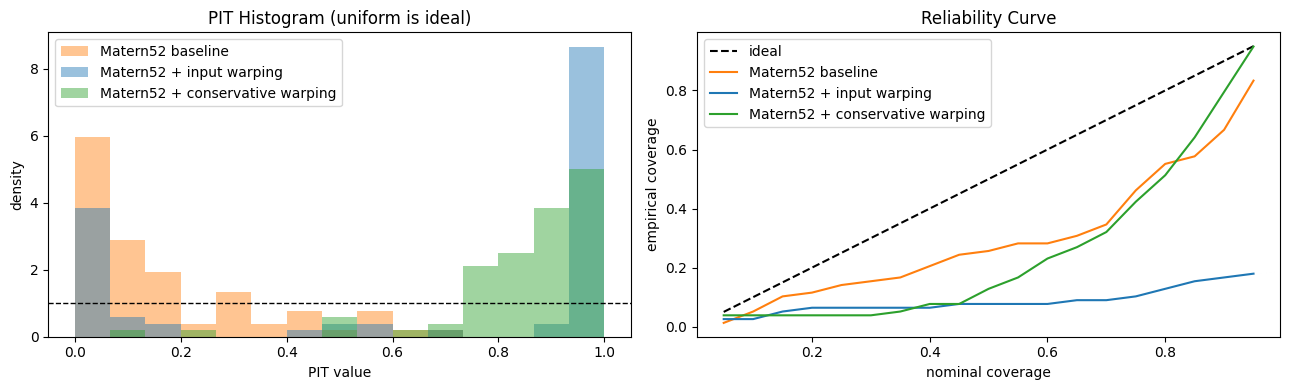

In [11]:
def normal_cdf_np(y: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    y_t = torch.tensor(y, dtype=torch.double)
    mean_t = torch.tensor(mean, dtype=torch.double)
    std_t = torch.tensor(np.maximum(std, 1e-12), dtype=torch.double)
    dist = torch.distributions.Normal(mean_t, std_t)
    return dist.cdf(y_t).cpu().numpy()


def calibration_summary(y: np.ndarray, mean: np.ndarray, var: np.ndarray) -> dict[str, float]:
    std = np.sqrt(np.maximum(var, 1e-12))
    z = np.abs(y - mean) / std
    # Two-sided Gaussian central intervals.
    cover_68 = float(np.mean(z <= 1.0))
    cover_95 = float(np.mean(z <= 1.959963984540054))
    avg_std = float(np.mean(std))
    avg_width_95 = float(np.mean(2.0 * 1.959963984540054 * std))
    return {
        "coverage_68": cover_68,
        "coverage_95": cover_95,
        "avg_std": avg_std,
        "avg_width_95": avg_width_95,
    }


model_results = [
    ("Matern52 baseline", baseline, "tab:orange"),
    ("Matern52 + input warping", warped, "tab:blue"),
    ("Matern52 + conservative warping", warped_conservative, "tab:green"),
]

rows = []
for name, result, _ in model_results:
    summary = calibration_summary(y_true, result["mean"], result["var"])
    summary["model"] = name
    rows.append(summary)

calibration_df = pd.DataFrame(rows)[["model", "coverage_68", "coverage_95", "avg_std", "avg_width_95"]]

print("Expected coverage targets: 68% -> 0.68, 95% -> 0.95")
calibration_df

pit_data = []
for name, result, color in model_results:
    pit_values = normal_cdf_np(y_true, result["mean"], np.sqrt(np.maximum(result["var"], 1e-12)))
    pit_data.append((name, pit_values, color))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0.0, 1.0, 16)
for name, pit_values, color in pit_data:
    axes[0].hist(pit_values, bins=bins, alpha=0.45, label=name, color=color, density=True)
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("PIT Histogram (uniform is ideal)")
axes[0].set_xlabel("PIT value")
axes[0].set_ylabel("density")
axes[0].legend(loc="best")

nominal_levels = np.linspace(0.05, 0.95, 19)
axes[1].plot(nominal_levels, nominal_levels, "k--", label="ideal")
for name, result, color in model_results:
    std = np.sqrt(np.maximum(result["var"], 1e-12))
    empirical = []
    for p in nominal_levels:
        z_thr = torch.distributions.Normal(0.0, 1.0).icdf(torch.tensor((1.0 + p) / 2.0)).item()
        empirical.append(float(np.mean(np.abs(y_true - result["mean"]) <= z_thr * std)))
    axes[1].plot(nominal_levels, empirical, color=color, label=name)

axes[1].set_title("Reliability Curve")
axes[1].set_xlabel("nominal coverage")
axes[1].set_ylabel("empirical coverage")
axes[1].legend(loc="best")

plt.tight_layout()

In [12]:
comparison = metrics.merge(calibration_df, on="model", how="left")
comparison.sort_values("NLL")

,model,RMSE,MAE,NLL,coverage_68,coverage_95,avg_std,avg_width_95
1,Matern52 + conservative warping,0.730095,0.578533,0.654007,0.307692,0.948718,0.408296,1.600489
2,Matern52 baseline,0.741545,0.655771,1.609470,0.320513,0.833333,0.574536,2.252139
0,Matern52 + input warping,0.197434,0.157065,47.725223,0.089744,0.179487,0.019929,0.078121


## Two-Input Example: Time + Random Covariate

Goal: show a case where time is monotonic with output and time-feature input warping can help in a model that also uses a second random covariate.

Latent structure used below: $y \approx f(\sqrt{time}) + 0.8\,x_{rand} + \epsilon$

Because the time effect is monotonic but nonlinear, warping the time coordinate can make the process closer to stationary in transformed space.

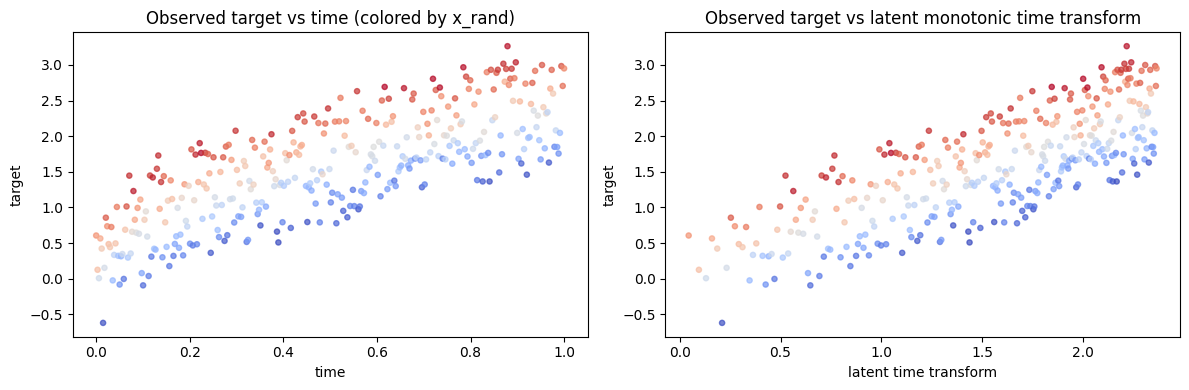

In [13]:
# Build a 2D dataset: time + random covariate
n2 = 340
time2 = np.linspace(0.0, 1.0, n2)
x_rand2 = np.random.uniform(-1.0, 1.0, size=n2)

# Monotonic-but-nonlinear time signal + linear random-covariate effect
time_latent2 = 1.4 * np.sqrt(time2 + 1e-3) + 0.6 * np.log1p(4.0 * time2)
signal2 = time_latent2 + 0.8 * x_rand2
noise2 = np.random.normal(0.0, 0.10, size=n2)
y2 = signal2 + noise2

df2 = pd.DataFrame(
    {
        "time": time2,
        "x_rand": x_rand2,
        "time_latent": time_latent2,
        "target": y2,
    }
)

split2 = int(0.7 * n2)
train_df2 = df2.iloc[:split2].copy()
test_df2 = df2.iloc[split2:].copy()

train_X2 = torch.tensor(train_df2[["time", "x_rand"]].values, dtype=torch.double)
train_Y2 = torch.tensor(train_df2[["target"]].values, dtype=torch.double)
test_X2 = torch.tensor(test_df2[["time", "x_rand"]].values, dtype=torch.double)
test_Y2 = torch.tensor(test_df2[["target"]].values, dtype=torch.double)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df2["time"], df2["target"], c=df2["x_rand"], cmap="coolwarm", s=14, alpha=0.7)
axes[0].set_title("Observed target vs time (colored by x_rand)")
axes[0].set_xlabel("time")
axes[0].set_ylabel("target")

axes[1].scatter(df2["time_latent"], df2["target"], c=df2["x_rand"], cmap="coolwarm", s=14, alpha=0.7)
axes[1].set_title("Observed target vs latent monotonic time transform")
axes[1].set_xlabel("latent time transform")
axes[1].set_ylabel("target")

plt.tight_layout()

In [14]:
baseline_2input_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(kernel_type=KernelType.MATERN_52),
        ),
        FeatureGroupSpec(
            name="random_covariate",
            feature_indices=[1],
            kernel=KernelSpec(kernel_type=KernelType.MATERN_52),
        ),
    ],
    input_dim=2,
    output_dim=1,
)

warped_2input_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(kernel_type=KernelType.MATERN_52),
        ),
        FeatureGroupSpec(
            name="random_covariate",
            feature_indices=[1],
            kernel=KernelSpec(kernel_type=KernelType.MATERN_52),
        ),
    ],
    execution=ExecutionSpec(
        input_scaling=True,
        outcome_standardization=True,
        input_warping=InputWarpingSpec(
            warp_type=WarpType.KUMARASWAMY,
            time_feature_index=0,
            concentration0=1.6,
            concentration1=0.7,
        ),
    ),
    input_dim=2,
    output_dim=1,
)

baseline_2input = fit_predict(baseline_2input_spec, train_X2, train_Y2, test_X2)
warped_2input = fit_predict(warped_2input_spec, train_X2, train_Y2, test_X2)

y2_true = test_Y2.squeeze(-1).cpu().numpy()
metrics_2input = pd.DataFrame(
    [
        {
            "model": "2D baseline (no warping)",
            "RMSE": rmse(y2_true, baseline_2input["mean"]),
            "MAE": mae(y2_true, baseline_2input["mean"]),
            "NLL": nll_gaussian(y2_true, baseline_2input["mean"], baseline_2input["var"]),
        },
        {
            "model": "2D + time input warping",
            "RMSE": rmse(y2_true, warped_2input["mean"]),
            "MAE": mae(y2_true, warped_2input["mean"]),
            "NLL": nll_gaussian(y2_true, warped_2input["mean"], warped_2input["var"]),
        },
    ]
).sort_values("RMSE")

metrics_2input

,model,RMSE,MAE,NLL
0,2D baseline (no warping),0.188687,0.161592,0.920349
1,2D + time input warping,0.205883,0.167689,4.019025


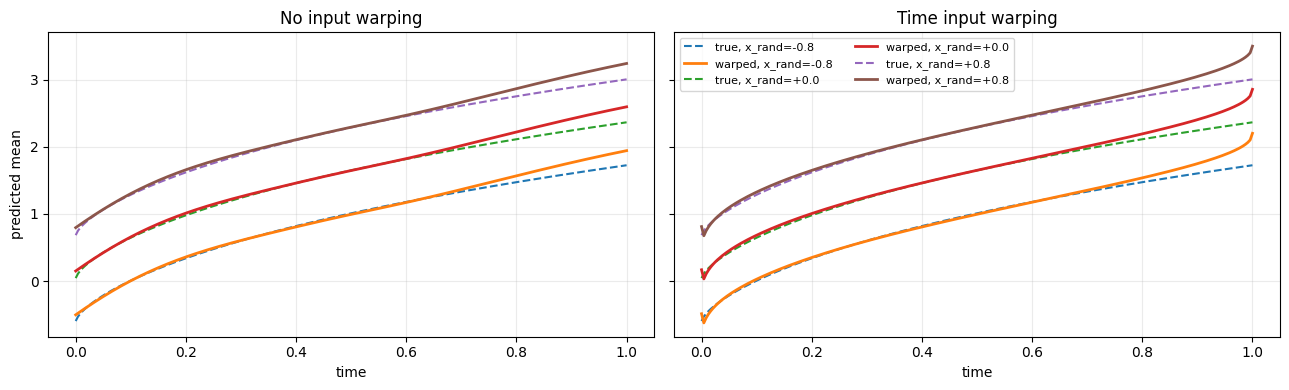

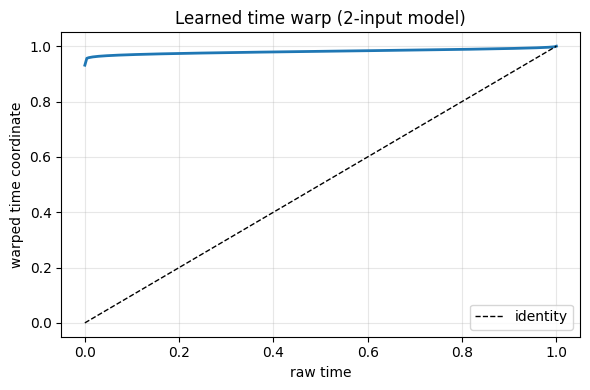

In [15]:
# Visualize how models behave along the time axis at fixed random covariate values
def posterior_mean_np(model: torch.nn.Module, X_np: np.ndarray) -> np.ndarray:
    X_t = torch.tensor(X_np, dtype=torch.double)
    model.eval()
    model.likelihood.eval()
    with torch.no_grad():
        p = model.posterior(X_t)
        return p.mean.squeeze(-1).cpu().numpy()


time_grid = np.linspace(0.0, 1.0, 240)
x_levels = [-0.8, 0.0, 0.8]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for x_level in x_levels:
    X_grid = np.column_stack([time_grid, np.full_like(time_grid, x_level)])

    mean_base = posterior_mean_np(baseline_2input["model"], X_grid)
    mean_warp = posterior_mean_np(warped_2input["model"], X_grid)
    true_curve = 1.4 * np.sqrt(time_grid + 1e-3) + 0.6 * np.log1p(4.0 * time_grid) + 0.8 * x_level

    axes[0].plot(time_grid, true_curve, linestyle="--", linewidth=1.5, label=f"true, x_rand={x_level:+.1f}")
    axes[0].plot(time_grid, mean_base, linewidth=2, label=f"baseline, x_rand={x_level:+.1f}")

    axes[1].plot(time_grid, true_curve, linestyle="--", linewidth=1.5, label=f"true, x_rand={x_level:+.1f}")
    axes[1].plot(time_grid, mean_warp, linewidth=2, label=f"warped, x_rand={x_level:+.1f}")

axes[0].set_title("No input warping")
axes[1].set_title("Time input warping")
for ax in axes:
    ax.set_xlabel("time")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("predicted mean")
axes[1].legend(loc="best", ncol=2, fontsize=8)
plt.tight_layout()

# Show learned warping map for the time dimension while keeping x_rand fixed
x_fixed = 0.0
X_raw = np.column_stack([time_grid, np.full_like(time_grid, x_fixed)])
with torch.no_grad():
    transformed = warped_2input["model"].input_transform(torch.tensor(X_raw, dtype=torch.double)).cpu().numpy()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_grid, transformed[:, 0], color="tab:blue", linewidth=2)
ax.plot(time_grid, time_grid, "k--", linewidth=1, label="identity")
ax.set_title("Learned time warp (2-input model)")
ax.set_xlabel("raw time")
ax.set_ylabel("warped time coordinate")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()

A monotonic time relationship does not guarantee warping is always best, but it is a strong signal that warping may help when the raw-time process appears nonstationary. Compare `metrics_2input` and the time-slice plots above to assess whether it improved both fit and uncertainty for this dataset.

## Takeaway

Input warping is most useful when at least one input (often time) has a monotonic but nonlinear relationship with the target.

In the 2-input example above, the model still uses the random covariate directly while warping only the time feature. The time-warped model can better align with latent monotonic dynamics, which can improve out-of-sample fit and uncertainty calibration when raw-time stationarity is a poor assumption.